## 0. Installs
(diffusers must come from source for `Flux2KleinPipeline`)

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!pip install -q onnxruntime numpy pillow opencv-python "rembg[gpu]"
!pip install -q --upgrade transformers accelerate
# Flux2KleinPipeline needs diffusers from source (not the pip release yet):
!pip install -q git+https://github.com/huggingface/diffusers.git
!pip install -q --force-reinstall "numpy<2.2" scipy

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rembg 2.0.83 requires numpy<3.0.0,>=2.3.0, but you have numpy 2.1.3 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.67.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.67.0 which is incompatible.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.67.0 which is incompatible.
cucim-cu12 26.2.1 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


## 1. Deblur
NAFNet via onnxruntime — no OpenCV DNN needed. Upload your photo as `/content/blur.jpeg` first.

In [ ]:
!git clone https://huggingface.co/opencv/deblurring_nafnet

fatal: destination path 'deblurring_nafnet' already exists and is not an empty directory.


In [ ]:
import cv2, numpy as np, onnxruntime as ort

MODEL  = "/content/deblurring_nafnet/deblurring_nafnet_2025may.onnx"
INPUT  = "/content/blur.jpeg"          # <-- your uploaded photo
OUTPUT = "/content/deblurred.jpg"

img = cv2.imread(INPUT)
img = cv2.resize(img, (512, 512))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
inp = img.astype(np.float32) / 255.0
inp = np.transpose(inp, (2, 0, 1))[None, ...]          # (1,3,H,W)

sess = ort.InferenceSession(MODEL, providers=["CPUExecutionProvider"])
out  = sess.run(None, {sess.get_inputs()[0].name: inp})[0]

out = np.squeeze(out, 0)
out = np.transpose(out, (1, 2, 0))
out = (np.clip(out, 0, 1) * 255).astype(np.uint8)
cv2.imwrite(OUTPUT, cv2.cvtColor(out, cv2.COLOR_RGB2BGR))
print("Deblurred ->", OUTPUT)

Deblurred -> /content/deblurred.jpg


## 2. Low-light fix
Runs MIRNet only if the image is actually dark (brightness < 80).

In [ ]:
img = cv2.imread("/content/deblurred.jpg")
brightness = np.mean(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
needs_enhancement = brightness < 80
print(f"brightness={brightness:.1f}  needs_enhancement={needs_enhancement}")

if needs_enhancement:
    import os, subprocess, sys, torch
    from huggingface_hub import hf_hub_download

    mirnet_path = hf_hub_download(
        repo_id="dblasko/mirnet-low-light-img-enhancement",
        filename="mirnet_finetuned.pth")
    if not os.path.exists("/content/mirnet-low-light-img-enhancement"):
        subprocess.run(["git", "clone",
            "https://huggingface.co/dblasko/mirnet-low-light-img-enhancement"],
            cwd="/content")
    sys.path.append("/content/mirnet-low-light-img-enhancement")

    from model.MIRNet.model import MIRNet
    from PIL import Image
    import torchvision.transforms as T

    device = "cuda" if torch.cuda.is_available() else "cpu"
    mirnet = MIRNet().to(device)
    mirnet.load_state_dict(torch.load(mirnet_path, map_location=device)["model_state_dict"])
    mirnet.eval()

    im = Image.open("/content/deblurred.jpg").convert("RGB")
    t  = T.Compose([T.Resize(400), T.ToTensor()])(im).unsqueeze(0).to(device)
    t  = t[:, :, :t.shape[2]//8*8, :t.shape[3]//8*8]     # H,W divisible by 8
    with torch.no_grad():
        o = mirnet(t)
    T.ToPILImage()(o.squeeze(0).cpu().clamp(0, 1)).save("/content/enhanced.jpg")
    restored = "/content/enhanced.jpg"
else:
    print("Image already well-lit — skipping enhancement.")
    restored = "/content/deblurred.jpg"

print("Restored ->", restored)

brightness=138.4  needs_enhancement=False
Image already well-lit — skipping enhancement.
Restored -> /content/deblurred.jpg


## 3. Background removal → clean product on white
Gives FLUX an isolated subject so it only builds the scene, helping preserve the product's identity.

In [ ]:
!pip install -q --force-reinstall "numpy==2.3.2" "scipy>=1.14,<1.18"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.67.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.67.0 which is incompatible.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.67.0 which is incompatible.
cucim-cu12 26.2.1 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


In [ ]:
import numpy, scipy
print("numpy", numpy.__version__)
print("scipy", scipy.__version__)
import rembg
print("rembg OK")

numpy 2.3.2
scipy 1.17.1
rembg OK


Isolated product -> /content/product_isolated.jpg


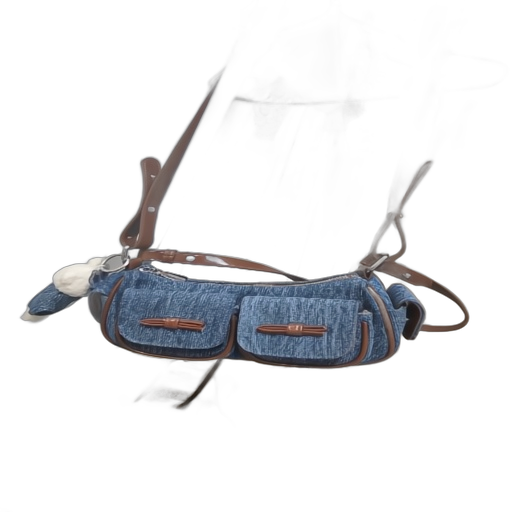

In [ ]:
from rembg import remove, new_session
from PIL import Image

session = new_session("isnet-general-use")   # sharper than default on clutter
src     = Image.open(restored).convert("RGB")
src.thumbnail((1024, 1024))
cutout  = remove(src, session=session)       # RGBA

white = Image.new("RGB", cutout.size, (255, 255, 255))
white.paste(cutout, (0, 0), cutout)          # composite over white
white.save("/content/product_isolated.jpg")
print("Isolated product -> /content/product_isolated.jpg")
white

## 4. FLUX.2 klein — studio relight (the professional photo)

If you're on an **old T4**, change `torch.bfloat16` to `torch.float16`.
Check the logo/text in `final.jpg` against `product_isolated.jpg` — if it drifts,
raise `num_inference_steps` to 6–8, or fall back to the composite-only path.

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Professional photo -> /content/final.jpg


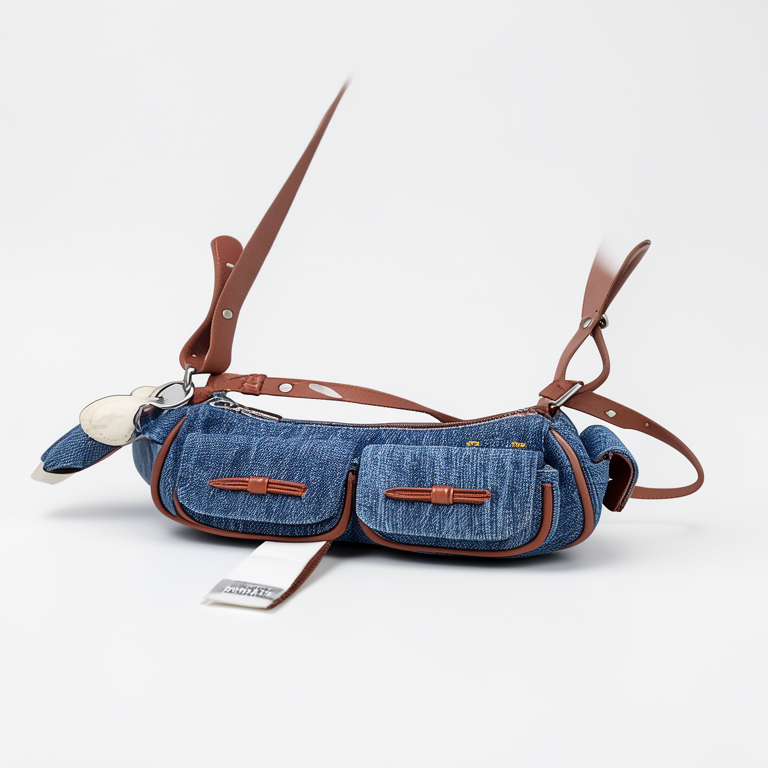

In [ ]:
import torch, gc
from diffusers import Flux2KleinPipeline
from PIL import Image

# free up VRAM left over from the deblur / MIRNet / rembg steps
gc.collect()
torch.cuda.empty_cache()

pipe = Flux2KleinPipeline.from_pretrained(
    "black-forest-labs/FLUX.2-klein-4B",
    torch_dtype=torch.bfloat16,          # use torch.float16 if you're on an old T4
)
pipe.enable_sequential_cpu_offload()     # lighter on VRAM than model_cpu_offload (a bit slower)

# Fixed prompt — never shown to the user
PROMPT = (
    "Transform this into a professional commercial product photograph. "
    "Preserve the exact product shown: its shape, proportions, colors, "
    "packaging, branding, logos, labels and text — do not redesign or "
    "invent anything. Place it in a clean professional studio, with soft "
    "studio lighting, natural contact shadows, subtle realistic reflections, "
    "sharp product details, centered composition and photorealistic rendering, "
    "as if shot by a professional e-commerce photographer."
)

SIZE = 768   # drop to 640 or 512 if you still hit OOM; upscale the result later if needed
product = Image.open("/content/product_isolated.jpg").convert("RGB").resize((SIZE, SIZE))

result = pipe(
    prompt=PROMPT,
    image=product,                        # passing image = editing / reference mode
    height=SIZE,
    width=SIZE,
    guidance_scale=1.0,
    num_inference_steps=4,                # klein is distilled to 4 steps
    generator=torch.Generator("cuda").manual_seed(0),
).images[0]

result.save("/content/final.jpg")
print("Professional photo -> /content/final.jpg")
result